# Imports

In [11]:
import os
import glob
import random
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Configuration

In [12]:
CONFIG = {
    "data_root": "/home/user/machine learning/OpenCV_bootcamp/Dataset",
    "epochs": 10,
    "batch_size": 64,
    "lr": 1e-3,
    "margin": 1.0,
    "thresh": 0.8,
    "hid": 128,
    "emb": 64,
    "use_fcm": True,
    "fcm_k": 3,
    "out_dir": "checkpoints",
    "use_cpu": False
}

# All Functions + Classes

In [13]:
# ---------------------------
# Gabor-based preprocessing
# ---------------------------
def gabor_preprocess(img_bgr: np.ndarray) -> np.ndarray:
    if img_bgr is None:
        raise ValueError("Invalid image")

    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)

    ksize = 9
    sigmas = [2.0, 3.0]
    thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    lambdas = [6.0, 8.0]
    gammas = [0.5, 0.8]

    accum = np.zeros_like(img_gray, dtype=np.float32)
    count = 0

    for sigma in sigmas:
        for theta in thetas:
            for lam in lambdas:
                for gamma in gammas:
                    kernel = cv2.getGaborKernel(
                        (ksize, ksize),
                        sigma,
                        theta,
                        lam,
                        gamma,
                        0,
                        ktype=cv2.CV_32F
                    )
                    resp = cv2.filter2D(img_gray, cv2.CV_32F, kernel)
                    accum += np.abs(resp)
                    count += 1

    accum /= max(count, 1)
    accum = cv2.normalize(accum, None, 0, 255, cv2.NORM_MINMAX)
    return accum.astype(np.uint8)


# ---------------------------
# Fuzzy C-means
# ---------------------------
def fuzzy_c_means_intensity(img_gray: np.ndarray, c=3, m=2.0, iters=8, seed=0):
    rng = np.random.default_rng(seed)
    x = img_gray.reshape(-1).astype(np.float32)

    centers = rng.choice(x, size=c, replace=False)
    U = rng.random((c, x.shape[0])).astype(np.float32)
    U /= (U.sum(axis=0, keepdims=True) + 1e-8)

    for _ in range(iters):
        um = U ** m
        centers = (um @ x) / (um.sum(axis=1) + 1e-8)

        dist = np.maximum(np.abs(x[None, :] - centers[:, None]), 1e-6)
        inv = 1.0 / dist
        inv_power = inv ** (2.0 / (m - 1.0))
        U = inv_power / (inv_power.sum(axis=0, keepdims=True) + 1e-8)

    return np.sort(centers)


# ---------------------------
# Feature Helpers
# ---------------------------
def dct_energy_features(img_gray):
    g = cv2.resize(img_gray, (128, 128)).astype(np.float32)
    dct = cv2.dct(g)
    total_energy = np.sum(dct**2) + 1e-8
    low = dct[:16, :16]
    low_energy = np.sum(low**2) + 1e-8
    high_ratio = (total_energy - low_energy) / total_energy
    return float(total_energy), float(high_ratio)


def edge_density(img_gray):
    edges = cv2.Canny(img_gray, 50, 150)
    return float(np.mean(edges > 0))


def luminance_mean_std(img_bgr):
    yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    y = yuv[:, :, 0]
    return float(np.mean(y)), float(np.std(y))


def color_stats(img_bgr):
    means = [float(np.mean(img_bgr[:, :, i])) for i in range(3)]
    stds = [float(np.std(img_bgr[:, :, i])) for i in range(3)]

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    means_hsv = [float(np.mean(hsv[:, :, i])) for i in range(3)]
    stds_hsv = [float(np.std(hsv[:, :, i])) for i in range(3)]

    return means + stds + means_hsv + stds_hsv


def gray_histogram(img_gray, bins=32):
    hist = cv2.calcHist([img_gray], [0], None, [bins], [0, 256]).reshape(-1)
    hist /= (np.sum(hist) + 1e-8)
    return hist.astype(np.float32)


# ---------------------------
# Feature Extraction
# ---------------------------
def extract_features(img_path, use_fcm=True, fcm_clusters=3):
    bgr = cv2.imread(img_path)
    if bgr is None:
        raise FileNotFoundError(f"Cannot read {img_path}")

    pre = gabor_preprocess(bgr)

    rgb_hsv = color_stats(bgr)
    lum_mean, lum_std = luminance_mean_std(bgr)
    hist = gray_histogram(pre)
    var = float(np.var(pre))
    edge = edge_density(pre)
    dct_total, dct_ratio = dct_energy_features(pre)

    feats = np.array(
        rgb_hsv + [lum_mean, lum_std, var, edge, dct_total, dct_ratio],
        dtype=np.float32
    )

    feats = np.concatenate([feats, hist])

    if use_fcm:
        centers = fuzzy_c_means_intensity(pre, c=fcm_clusters)
        feats = np.concatenate([feats, centers.astype(np.float32)])

    return feats


# ---------------------------
# Pair Dataset
# ---------------------------
class PairDataset(Dataset):
    def __init__(self, real_paths, fake_paths, use_fcm=True, fcm_clusters=3, cache=True):
        self.use_fcm = use_fcm
        self.fcm_clusters = fcm_clusters
        self.cache = cache
        self._feat_cache = {}

        self.all = [(p, 1) for p in real_paths] + [(p, 0) for p in fake_paths]

        self.real_idx = [i for i, (_, y) in enumerate(self.all) if y == 1]
        self.fake_idx = [i for i, (_, y) in enumerate(self.all) if y == 0]

        sample_feat = self._featurize(self.all[0][0])
        self.feat_dim = sample_feat.shape[0]

    def _featurize(self, path):
        if self.cache and path in self._feat_cache:
            return self._feat_cache[path]
        feat = extract_features(path, self.use_fcm, self.fcm_clusters)
        if self.cache:
            self._feat_cache[path] = feat
        return feat

    def __len__(self):
        return max(1000, 2 * len(self.all))

    def __getitem__(self, idx):
        genuine = (idx % 2 == 0)

        if genuine:
            cls = random.choice([0, 1])
            pool = self.real_idx if cls == 1 else self.fake_idx
            i1, i2 = random.sample(pool, 2)
        else:
            i1 = random.choice(self.real_idx)
            i2 = random.choice(self.fake_idx)

        f1 = self._featurize(self.all[i1][0])
        f2 = self._featurize(self.all[i2][0])

        label = 1.0 if genuine else 0.0

        return (
            torch.from_numpy(f1).float(),
            torch.from_numpy(f2).float(),
            torch.tensor(label).float()
        )


# ---------------------------
# Siamese Network
# ---------------------------
class Encoder(nn.Module):
    def __init__(self, in_dim, hid=128, emb=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid),
            nn.ReLU(),
            nn.BatchNorm1d(hid),
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.BatchNorm1d(hid),
            nn.Linear(hid, emb)
        )

    def forward(self, x):
        return self.net(x)


class Siamese(nn.Module):
    def __init__(self, in_dim, hid=128, emb=64):
        super().__init__()
        self.enc = Encoder(in_dim, hid, emb)

    def forward(self, x1, x2):
        return self.enc(x1), self.enc(x2)


def contrastive_loss(z1, z2, label, margin=1.0):
    d = torch.nn.functional.pairwise_distance(z1, z2)
    pos = 0.5 * label * d**2
    neg = 0.5 * (1 - label) * torch.clamp(margin - d, min=0)**2
    return (pos + neg).mean(), d


# ---------------------------
# Utilities
# ---------------------------
def list_images(root):
    if not os.path.exists(root):
        print("Path not found:", root)
        return [], []

    # Accept both lowercase & uppercase
    real_dir = None
    fake_dir = None

    for folder in os.listdir(root):
        if folder.lower() == "real":
            real_dir = os.path.join(root, folder)
        if folder.lower() == "fake":
            fake_dir = os.path.join(root, folder)

    if real_dir is None or fake_dir is None:
        print("Real/Fake folders not found inside:", root)
        return [], []

    exts = {".jpg", ".jpeg", ".png", ".bmp"}

    real = [
        os.path.join(real_dir, f)
        for f in os.listdir(real_dir)
        if os.path.splitext(f)[1].lower() in exts
    ]

    fake = [
        os.path.join(fake_dir, f)
        for f in os.listdir(fake_dir)
        if os.path.splitext(f)[1].lower() in exts
    ]

    return real, fake


def accuracy_from_dist(dists, labels, thresh=0.8):
    preds = (dists < thresh).float()
    return (preds == labels).float().mean().item()

# EDA (Exploratory Data Analysis)

Using subset:
Train Real: 2500
Train Fake: 2500
Val Real: 1000
Val Fake: 1000


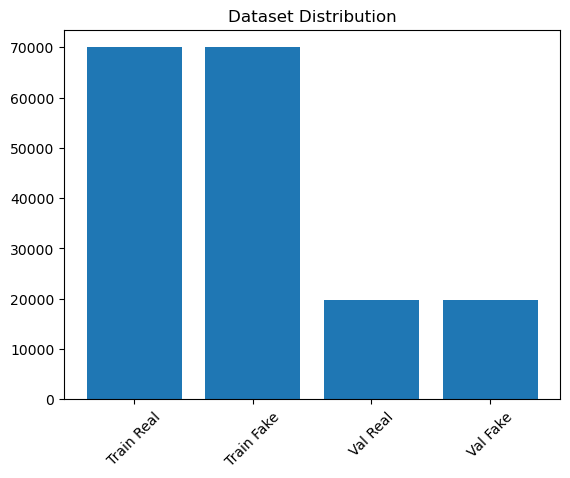

Showing Sample Images...


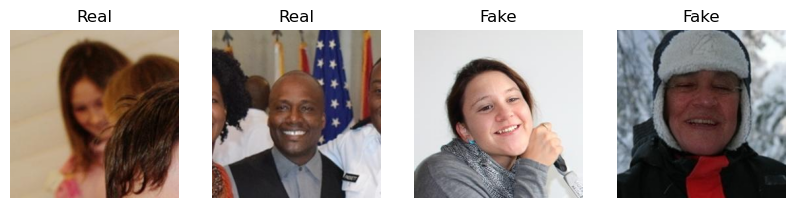

In [15]:
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import pandas as pd

def run_eda(data_root):
    train_real, train_fake = list_images(os.path.join(data_root, "Train"))
    val_real, val_fake = list_images(os.path.join(data_root, "Validation"))

    MAX_TRAIN = 5000
    MAX_VAL = 2000

    tr_real = train_real[:MAX_TRAIN//2]
    tr_fake = train_fake[:MAX_TRAIN//2]

    va_real = val_real[:MAX_VAL//2]
    va_fake = val_fake[:MAX_VAL//2]

    print("Using subset:")
    print("Train Real:", len(tr_real))
    print("Train Fake:", len(tr_fake))
    print("Val Real:", len(va_real))
    print("Val Fake:", len(va_fake))

    # Bar plot
    labels = ['Train Real', 'Train Fake', 'Val Real', 'Val Fake']
    values = [len(train_real), len(train_fake), len(val_real), len(val_fake)]

    plt.figure()
    plt.bar(labels, values)
    plt.title("Dataset Distribution")
    plt.xticks(rotation=45)
    plt.show()

    # Show sample images
    print("Showing Sample Images...")
    sample_paths = train_real[:2] + train_fake[:2]

    plt.figure(figsize=(10,5))
    for i, path in enumerate(sample_paths):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1,4,i+1)
        plt.imshow(img)
        plt.title("Real" if i<2 else "Fake")
        plt.axis("off")
    plt.show()

# Run EDA
run_eda(CONFIG["data_root"])

# Training Function

In [16]:
def train_model(cfg):
    # Data paths
    MAX_TRAIN = 5000
    MAX_VAL = 2000
    train_real, train_fake = list_images(os.path.join(cfg["data_root"], "Train"))
    val_real, val_fake = list_images(os.path.join(cfg["data_root"], "Validation"))

    tr_real = train_real[:MAX_TRAIN//2]
    tr_fake = train_fake[:MAX_TRAIN//2]

    va_real = val_real[:MAX_VAL//2]
    va_fake = val_fake[:MAX_VAL//2]
    
    if len(tr_real) < 2 or len(tr_fake) < 2:
        raise RuntimeError("Need at least 2 images per class.")

    train_ds = PairDataset(tr_real, tr_fake,
                           use_fcm=cfg["use_fcm"],
                           fcm_clusters=cfg["fcm_k"],
                           cache=True)

    val_ds = PairDataset(va_real, va_fake,
                         use_fcm=cfg["use_fcm"],
                         fcm_clusters=cfg["fcm_k"],
                         cache=True)

    train_loader = DataLoader(train_ds,
                              batch_size=cfg["batch_size"],
                              shuffle=True,
                              num_workers=0,
                              drop_last=True)

    val_loader = DataLoader(val_ds,
                            batch_size=cfg["batch_size"],
                            shuffle=False,
                            num_workers=0)

    device = torch.device("cuda" if torch.cuda.is_available() and not cfg["use_cpu"] else "cpu")

    model = Siamese(train_ds.feat_dim,
                    hid=cfg["hid"],
                    emb=cfg["emb"]).to(device)

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg["lr"],
                                 weight_decay=1e-4)

    best_val = 0.0

    for epoch in range(cfg["epochs"]):
        model.train()
        total_loss = 0

        for f1, f2, y in train_loader:
            f1, f2, y = f1.to(device), f2.to(device), y.to(device)

            optimizer.zero_grad()
            z1, z2 = model(f1, f2)
            loss, d = contrastive_loss(z1, z2, y, margin=cfg["margin"])
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Validation
        model.eval()
        all_d, all_y = [], []

        with torch.no_grad():
            for f1, f2, y in val_loader:
                f1, f2 = f1.to(device), f2.to(device)
                z1, z2 = model(f1, f2)
                _, d = contrastive_loss(z1, z2, y.to(device), margin=cfg["margin"])
                all_d.append(d.cpu())
                all_y.append(y)

        dists = torch.cat(all_d)
        labels = torch.cat(all_y)
        acc = accuracy_from_dist(dists, labels, thresh=cfg["thresh"])

        avg_loss = total_loss / len(train_loader)

        print(f"Epoch {epoch+1} | Loss={avg_loss:.4f} | Val Acc={acc*100:.2f}%")

        if acc > best_val:
            best_val = acc
            os.makedirs(cfg["out_dir"], exist_ok=True)
            torch.save({
                "state_dict": model.state_dict(),
                "feat_dim": train_ds.feat_dim
            }, os.path.join(cfg["out_dir"], "siamese_deepfake.pth"))
            print("✔ Best model saved")

    print("Training Finished")
    

# Run Training

In [10]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

train_model(CONFIG)

Epoch 1 | Loss=0.5033 | Val Acc=49.95%
✔ Best model saved
Epoch 2 | Loss=0.1508 | Val Acc=51.42%
✔ Best model saved
Epoch 3 | Loss=0.1583 | Val Acc=49.13%
Epoch 4 | Loss=0.1667 | Val Acc=50.10%
Epoch 5 | Loss=0.1566 | Val Acc=49.20%
Epoch 6 | Loss=0.1574 | Val Acc=49.08%
Epoch 7 | Loss=0.1612 | Val Acc=50.77%
Epoch 8 | Loss=0.1674 | Val Acc=49.75%
Epoch 9 | Loss=0.1769 | Val Acc=49.80%
Epoch 10 | Loss=0.1598 | Val Acc=50.33%
Training Finished


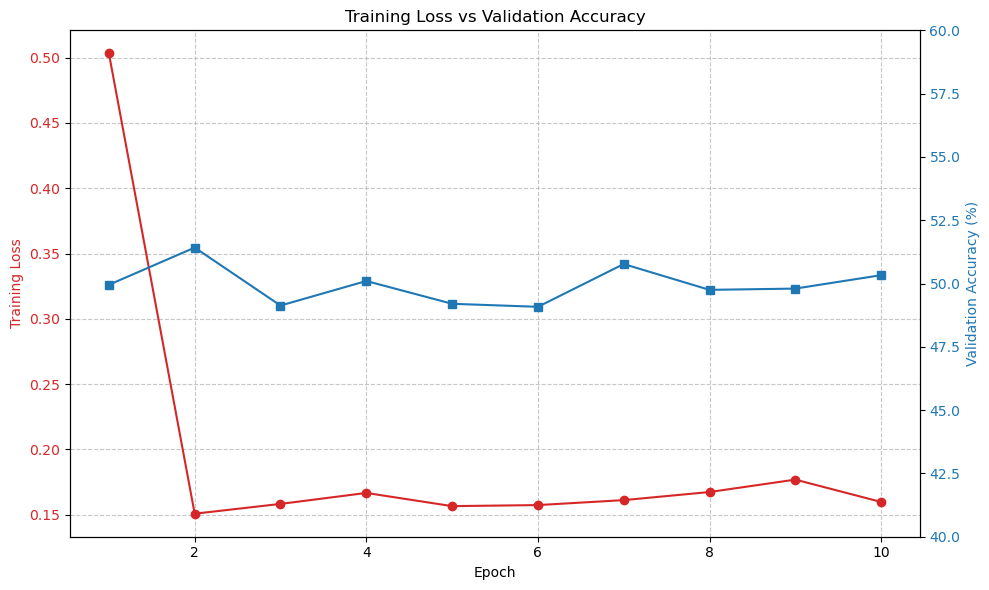

In [2]:
import matplotlib.pyplot as plt

# Data from the log
epochs = list(range(1, 11))
loss = [0.5033, 0.1508, 0.1583, 0.1667, 0.1566, 0.1574, 0.1612, 0.1674, 0.1769, 0.1598]
val_acc = [49.95, 51.42, 49.13, 50.10, 49.20, 49.08, 50.77, 49.75, 49.80, 50.33]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting Loss
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs, loss, color=color, marker='o', label='Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# Second y-axis for Accuracy
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy (%)', color=color)
ax2.plot(epochs, val_acc, color=color, marker='s', label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(40, 60) # Set to highlight fluctuations around 50%

plt.title('Training Loss vs Validation Accuracy')
fig.tight_layout()

# Save the plot
plt.savefig('training_graph.png')

# Graph Visualization Function

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

def plot_tsne(model, real_paths, fake_paths, cfg, num_samples=200):

    device = torch.device("cpu")
    model.eval()

    # Combine real + fake
    all_samples = [(p, 1) for p in real_paths] + [(p, 0) for p in fake_paths]

    if len(all_samples) < num_samples:
        num_samples = len(all_samples)

    samples = random.sample(all_samples, num_samples)

    embeddings = []
    labels = []

    for img_path, label in samples:

        feat = extract_features(img_path, cfg["use_fcm"], cfg["fcm_k"])
        feat = torch.from_numpy(feat).float().unsqueeze(0).to(device)

        with torch.no_grad():
            z, _ = model(feat, feat)
            embeddings.append(z.squeeze().cpu().numpy())
            labels.append(label)

    embeddings = np.array(embeddings)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 8))

    labels = np.array(labels)

    plt.scatter(reduced[labels==1, 0],
                reduced[labels==1, 1],
                label="Real",
                alpha=0.7)

    plt.scatter(reduced[labels==0, 0],
                reduced[labels==0, 1],
                label="Fake",
                alpha=0.7)

    plt.title("t-SNE Visualization of Embedding Space")
    plt.legend()
    plt.show()


def plot_distance_distribution(model, val_loader, device):

    model.eval()

    pos_distances = []
    neg_distances = []

    with torch.no_grad():
        for f1, f2, y in val_loader:

            f1 = f1.to(device)
            f2 = f2.to(device)

            z1, z2 = model(f1, f2)
            dist = torch.nn.functional.pairwise_distance(z1, z2)

            dist = dist.cpu().numpy()
            y_np = y.cpu().numpy()

            pos_distances.extend(dist[y_np == 1])
            neg_distances.extend(dist[y_np == 0])

    plt.figure(figsize=(10, 6))

    plt.hist(pos_distances,
             bins=50,
             alpha=0.5,
             label='Same Class (Positive)')

    plt.hist(neg_distances,
             bins=50,
             alpha=0.5,
             label='Different Class (Negative)')

    plt.title("Distance Distribution: Real vs Fake")
    plt.xlabel("Euclidean Distance")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

## execution part of it

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7c1944f62a20>
Traceback (most recent call last):
  File "/home/user/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/user/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/user/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

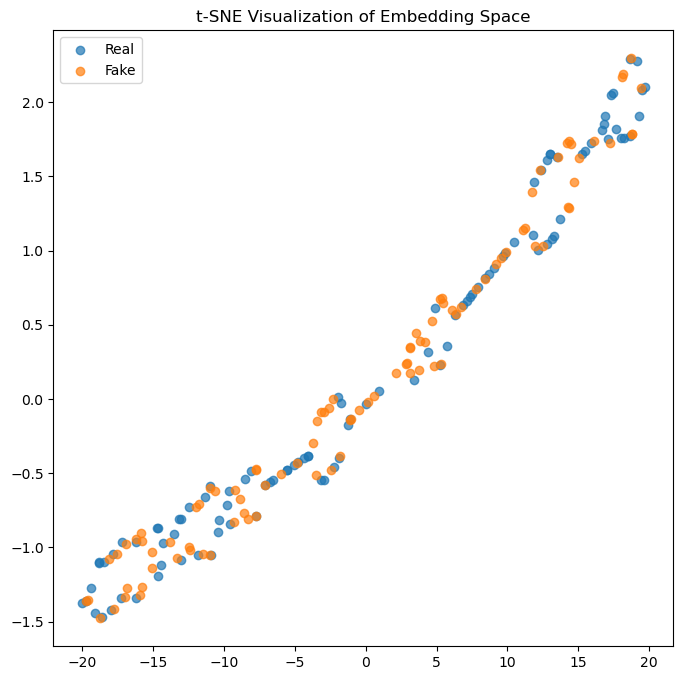

In [7]:
device = torch.device("cpu")

checkpoint = torch.load(
    "/home/user/machine learning/OpenCV_bootcamp/checkpoints/siamese_deepfake.pth",
    map_location=device
)

feat_dim = checkpoint["feat_dim"]

model = Siamese(feat_dim,
                hid=CONFIG["hid"],
                emb=CONFIG["emb"]).to(device)

model.load_state_dict(checkpoint["state_dict"])
model.eval()

train_real, train_fake = list_images(
    os.path.join(CONFIG["data_root"], "Train")
)
plot_tsne(model, train_real, train_fake, CONFIG, num_samples=200)

In [ ]:
val_real, val_fake = list_images(
    os.path.join(CONFIG["data_root"], "Validation")
)

val_ds = PairDataset(
    val_real,
    val_fake,
    use_fcm=CONFIG["use_fcm"],
    fcm_clusters=CONFIG["fcm_k"]
)

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
plot_distance_distribution(model, val_loader, device)

# Single Image Prediction

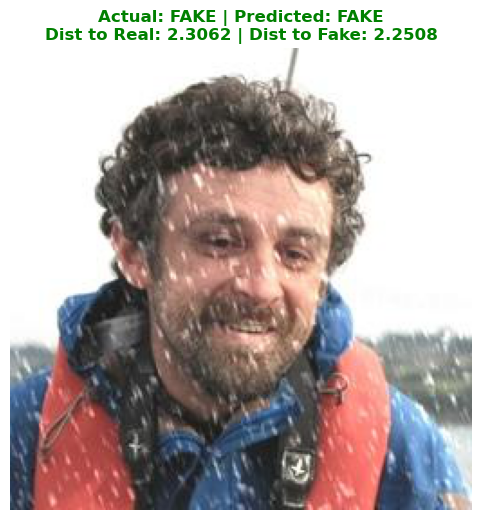

Result -> Actual: FAKE, Predicted: FAKE


In [23]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def predict_single_image(image_path, model_path, cfg):
    # 1. Determine Original (True) Label from the file path
    # If the path contains "/Real/", the true label is REAL, otherwise FAKE.
    if "Real" in image_path:
        true_label = "REAL"
    elif "Fake" in image_path:
        true_label = "FAKE"
    else:
        true_label = "Unknown"

    # 2. Load the checkpoint
    checkpoint = torch.load(model_path, map_location="cpu")
    feat_dim = checkpoint["feat_dim"]
    
    # 3. Initialize model with dimensions matching the checkpoint (128/64)
    model = Siamese(feat_dim, hid=cfg["hid"], emb=cfg["emb"])
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    
    # 4. Reference Images for Siamese comparison
    test_root = os.path.join(cfg["data_root"], "Test")
    real_paths, fake_paths = list_images(test_root)
    
    # Comparing against the first available references
    ref_real = extract_features(real_paths[0], cfg["use_fcm"], cfg["fcm_k"])
    ref_fake = extract_features(fake_paths[0], cfg["use_fcm"], cfg["fcm_k"])
    
    ref_real_t = torch.from_numpy(ref_real).float().unsqueeze(0)
    ref_fake_t = torch.from_numpy(ref_fake).float().unsqueeze(0)

    # 5. Prepare Target Image
    target_feat = extract_features(image_path, cfg["use_fcm"], cfg["fcm_k"])
    target_t = torch.from_numpy(target_feat).float().unsqueeze(0)

    # 6. Inference (Distance calculation)
    with torch.no_grad():
        z_target, z_ref_real = model(target_t, ref_real_t)
        _, z_ref_fake = model(target_t, ref_fake_t)
        
        dist_to_real = torch.nn.functional.pairwise_distance(z_target, z_ref_real).item()
        dist_to_fake = torch.nn.functional.pairwise_distance(z_target, z_ref_fake).item()

    # 7. Prediction Logic
    pred_label = "REAL" if dist_to_real < dist_to_fake else "FAKE"
    
    # 8. Visual Result with Comparison
    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(image_path))
    
    # Color coding: Green if correct, Red if wrong
    title_color = 'green' if true_label == pred_label else 'red'
    
    plt.title(f"Actual: {true_label} | Predicted: {pred_label}\n"
              f"Dist to Real: {dist_to_real:.4f} | Dist to Fake: {dist_to_fake:.4f}", 
              color=title_color, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

    return true_label, pred_label

# --- Execution ---
if __name__ == "__main__":
    MY_CONFIG = {
        "data_root": "/home/user/machine learning/OpenCV_bootcamp/Dataset",
        "use_fcm": True,
        "fcm_k": 3,
        "hid": 128,  
        "emb": 64,   
    }
    
    MODEL_PATH = "/home/user/machine learning/OpenCV_bootcamp/checkpoints/siamese_deepfake.pth"
    
    # Example test image
    IMAGE_TO_TEST = "/home/user/machine learning/OpenCV_bootcamp/Dataset/Test/Fake/fake_9.jpg" 

    if os.path.exists(IMAGE_TO_TEST):
        actual, predicted = predict_single_image(IMAGE_TO_TEST, MODEL_PATH, MY_CONFIG)
        print(f"Result -> Actual: {actual}, Predicted: {predicted}")
    else:
        print(f"File not found: {IMAGE_TO_TEST}")

# Confusion Matrix + Evaluation

--- Starting Evaluation ---
Loading model from: /home/user/machine learning/OpenCV_bootcamp/checkpoints/siamese_deepfake.pth
Extracting reference embeddings...
Classifying 100 images...

TEST RESULTS
              precision    recall  f1-score   support

    Fake (0)       0.49      0.58      0.53        50
    Real (1)       0.49      0.40      0.44        50

    accuracy                           0.49       100
   macro avg       0.49      0.49      0.49       100
weighted avg       0.49      0.49      0.49       100



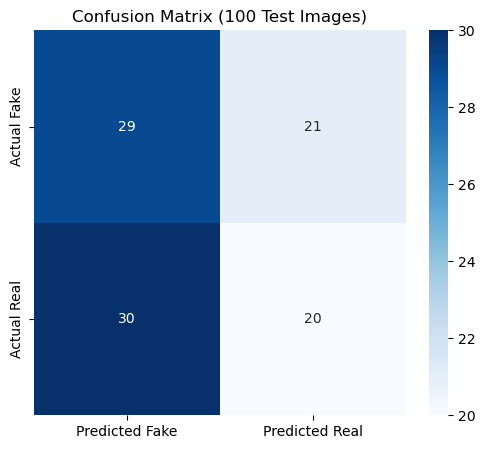

In [24]:
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

# --- Core Function ---

def test_on_100_images(cfg, model_path):
    print("--- Starting Evaluation ---")
    test_root = os.path.join(cfg["data_root"], "Test")

    # list_images should return two lists of full file paths
    real_paths, fake_paths = list_images(test_root)

    if len(real_paths) < 50 or len(fake_paths) < 50:
        print(f"Error: Found only {len(real_paths)} real and {len(fake_paths)} fake images. Need 50 each.")
        return

    # Select 50 real + 50 fake for testing
    real_sample = random.sample(real_paths, 50)
    fake_sample = random.sample(fake_paths, 50)

    test_images = real_sample + fake_sample
    true_labels = [1]*50 + [0]*50  # 1 = real, 0 = fake

    # Load model
    print(f"Loading model from: {model_path}")
    checkpoint = torch.load(model_path, map_location="cpu")
    feat_dim = checkpoint["feat_dim"]
    
    # Initialize your Siamese architecture
    model = Siamese(feat_dim, hid=cfg["hid"], emb=cfg["emb"])
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    # Get reference features (Using 5 images for a more stable 'average' reference)
    def get_ref_embedding(paths):
        embeddings = []
        for p in paths[:5]:
            f = extract_features(p, cfg["use_fcm"], cfg["fcm_k"])
            f_tensor = torch.from_numpy(f).float().unsqueeze(0)
            with torch.no_grad():
                # We only need the embedding output from the Siamese branch
                # Assuming model(x, x) returns (z1, z2)
                z, _ = model(f_tensor, f_tensor) 
                embeddings.append(z)
        return torch.mean(torch.stack(embeddings), dim=0)

    print("Extracting reference embeddings...")
    ref_real_z = get_ref_embedding(real_paths)
    ref_fake_z = get_ref_embedding(fake_paths)

    predictions = []

    print("Classifying 100 images...")
    for img_path in test_images:
        feat = extract_features(img_path, cfg["use_fcm"], cfg["fcm_k"])
        feat = torch.from_numpy(feat).float().unsqueeze(0)

        with torch.no_grad():
            # Get embedding for the current test image
            z_img, _ = model(feat, feat)
            
            # Calculate distance to Real vs Fake references
            dist_real = torch.nn.functional.pairwise_distance(z_img, ref_real_z)
            dist_fake = torch.nn.functional.pairwise_distance(z_img, ref_fake_z)

        if dist_real.item() < dist_fake.item():
            predictions.append(1)
        else:
            predictions.append(0)

    # --- Visualization & Metrics ---
    cm = confusion_matrix(true_labels, predictions)
    
    print("\n" + "="*30)
    print("TEST RESULTS")
    print("="*30)
    print(classification_report(true_labels, predictions, target_names=["Fake (0)", "Real (1)"]))

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["Predicted Fake", "Predicted Real"],
                yticklabels=["Actual Fake", "Actual Real"])
    plt.title("Confusion Matrix (100 Test Images)")
    plt.show()

# --- Execution Block ---

if __name__ == "__main__":

    MY_CONFIG = {
        "data_root": "/home/user/machine learning/OpenCV_bootcamp/Dataset",
        "use_fcm": True,
        "fcm_k": 3,
        "hid": 128,
        "emb": 64,
    }
    
    
    MODEL_FILE = "/home/user/machine learning/OpenCV_bootcamp/checkpoints/siamese_deepfake.pth"
   

    if os.path.exists(MODEL_FILE):
        test_on_100_images(MY_CONFIG, MODEL_FILE)
    else:
        print(f"ERROR: Model not found at {MODEL_FILE}")
        print("Please check if the path is relative to your current terminal location.")

#  Extention 

# Real-Time Video Deepfake Detection

# Frame Extraction

In [17]:
def extract_features_from_frame(frame, cfg):
    pre = gabor_preprocess(frame)

    rgb_hsv = color_stats(frame)
    lum_mean, lum_std = luminance_mean_std(frame)
    hist = gray_histogram(pre)
    var = float(np.var(pre))
    edge = edge_density(pre)
    dct_total, dct_ratio = dct_energy_features(pre)

    feats = np.array(
        rgb_hsv + [lum_mean, lum_std, var, edge, dct_total, dct_ratio],
        dtype=np.float32
    )

    feats = np.concatenate([feats, hist])

    if cfg["use_fcm"]:
        centers = fuzzy_c_means_intensity(pre, c=cfg["fcm_k"])
        feats = np.concatenate([feats, centers.astype(np.float32)])

    return feats

# Nomadic Detection

In [18]:
import cv2
import time
import torch
import numpy as np
import os

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def run_video_detection(cfg, model_path, video_source=0):

    device = torch.device("cpu")
    checkpoint = torch.load(model_path, map_location=device)
    feat_dim = checkpoint["feat_dim"]

    model = Siamese(feat_dim, hid=cfg["hid"], emb=cfg["emb"])
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    # Prepare reference embeddings
    train_root = os.path.join(cfg["data_root"], "Train")
    real_paths, fake_paths = list_images(train_root)

    def avg_embedding(paths):
        embeddings = []
        for p in paths[:5]:
            feat = extract_features(p, cfg["use_fcm"], cfg["fcm_k"])
            feat = torch.from_numpy(feat).float().unsqueeze(0)
            with torch.no_grad():
                z, _ = model(feat, feat)
            embeddings.append(z)
        return torch.mean(torch.stack(embeddings), dim=0)

    print("Preparing reference embeddings...")
    ref_real = avg_embedding(real_paths)
    ref_fake = avg_embedding(fake_paths)

    cap = cv2.VideoCapture(video_source)
    if not cap.isOpened():
        print("Error opening video source")
        return

    prev_gray = None
    last_label = "WAITING..."
    last_distance = 0
    motion_threshold = 5000

    print("Press Q to exit")

    while True:
        start_time = time.time()
        ret, frame = cap.read()
        if not ret:
            break

        frame_small = cv2.resize(frame, (320, 240))
        gray = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (21, 21), 0)

        motion_detected = False

        if prev_gray is None:
            prev_gray = gray
            continue

        frame_diff = cv2.absdiff(prev_gray, gray)
        thresh = cv2.threshold(frame_diff, 25, 255, cv2.THRESH_BINARY)[1]
        motion_score = np.sum(thresh)

        if motion_score > motion_threshold:
            motion_detected = True

        prev_gray = gray

        # =============================
        # FACE + DEEPFAKE PREDICTION
        # =============================
        if motion_detected:
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.3,
                minNeighbors=5,
                minSize=(60, 60)
            )

            for (x, y, w_box, h_box) in faces:

                face_roi = frame_small[y:y+h_box, x:x+w_box]
                face_roi = cv2.resize(face_roi, (160, 160))

                try:
                    feat = extract_features_from_frame(face_roi, cfg)
                    feat = torch.from_numpy(feat).float().unsqueeze(0)

                    with torch.no_grad():
                        z_img, _ = model(feat, feat)
                        dist_real = torch.nn.functional.pairwise_distance(z_img, ref_real)
                        dist_fake = torch.nn.functional.pairwise_distance(z_img, ref_fake)

                    if dist_real.item() < dist_fake.item():
                        last_label = "REAL"
                        last_distance = dist_real.item()
                        main_color = (0, 255, 0)
                    else:
                        last_label = "FAKE"
                        last_distance = dist_fake.item()
                        main_color = (0, 0, 255)

                except:
                    continue

                # Scale face box to original frame
                scale_x = frame.shape[1] / 320
                scale_y = frame.shape[0] / 240

                x1 = int(x * scale_x)
                y1 = int(y * scale_y)
                x2 = int((x + w_box) * scale_x)
                y2 = int((y + h_box) * scale_y)

                # Glow effect
                for i in range(1, 5):
                    overlay = frame.copy()
                    cv2.rectangle(overlay,
                                  (x1 - i*3, y1 - i*3),
                                  (x2 + i*3, y2 + i*3),
                                  main_color, 2)
                    frame = cv2.addWeighted(overlay, 0.2, frame, 0.8, 0)

                # Main rectangle
                cv2.rectangle(frame, (x1, y1), (x2, y2), main_color, 3)

                # Label above face
                cv2.putText(frame,
                            last_label,
                            (x1, y1 - 10),
                            cv2.FONT_HERSHEY_DUPLEX,
                            0.8,
                            main_color,
                            2)

        # =============================
        # TOP UI PANEL
        # =============================
        h, w = frame.shape[:2]

        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (w, 110), (20, 20, 20), -1)
        frame = cv2.addWeighted(overlay, 0.75, frame, 0.25, 0)

        # Big label
        cv2.putText(frame, last_label,
                    (30, 70),
                    cv2.FONT_HERSHEY_DUPLEX,
                    1.5,
                    (0, 0, 0),
                    6)

        cv2.putText(frame, last_label,
                    (30, 70),
                    cv2.FONT_HERSHEY_DUPLEX,
                    1.5,
                    (0, 255, 0) if last_label == "REAL" else (0, 0, 255),
                    3)

        # Distance
        cv2.putText(frame,
                    f"Distance: {last_distance:.3f}",
                    (30, 100),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255, 255, 255),
                    2)

        # FPS
        fps = 1 / (time.time() - start_time)
        cv2.putText(frame,
                    f"FPS: {fps:.1f}",
                    (w - 150, 40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (255, 255, 255),
                    2)

        cv2.imshow("Smart Deepfake Detector", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Smart Enhanced Detection

In [19]:
import cv2
import time
import torch
import numpy as np
import os
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
def run_video_detection_smart(cfg, model_path, video_source=0):

    # Load model
    device = torch.device("cpu")
    checkpoint = torch.load(model_path, map_location=device)
    feat_dim = checkpoint["feat_dim"]

    model = Siamese(feat_dim, hid=cfg["hid"], emb=cfg["emb"])
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    # Reference embeddings
    train_root = os.path.join(cfg["data_root"], "Train")
    real_paths, fake_paths = list_images(train_root)

    def avg_embedding(paths):
        emb = []
        for p in paths[:5]:
            feat = extract_features(p, cfg["use_fcm"], cfg["fcm_k"])
            feat = torch.from_numpy(feat).float().unsqueeze(0)
            with torch.no_grad():
                z, _ = model(feat, feat)
            emb.append(z)
        return torch.mean(torch.stack(emb), dim=0)

    print("Preparing reference embeddings...")
    ref_real = avg_embedding(real_paths)
    ref_fake = avg_embedding(fake_paths)

    cap = cv2.VideoCapture(video_source)
    if not cap.isOpened():
        print("Error opening video source")
        return

    prev_gray = None
    last_label = "WAITING..."
    last_distance = 0
    motion_threshold = 5000  # tune if needed

    print("Press Q to exit")

    while True:
        start_time = time.time()
        ret, frame = cap.read()
        if not ret:
            break

        frame_small = cv2.resize(frame, (320, 240))
        gray = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (21, 21), 0)

        motion_detected = False

        if prev_gray is None:
            prev_gray = gray
            continue

        frame_diff = cv2.absdiff(prev_gray, gray)
        thresh = cv2.threshold(frame_diff, 25, 255, cv2.THRESH_BINARY)[1]
        motion_score = np.sum(thresh)

        if motion_score > motion_threshold:
            motion_detected = True

        prev_gray = gray

        # Only predict if motion detected
        if motion_detected:
            try:
                feat = extract_features_from_frame(frame_small, cfg)
                feat = torch.from_numpy(feat).float().unsqueeze(0)

                with torch.no_grad():
                    z_img, _ = model(feat, feat)

                    dist_real = torch.nn.functional.pairwise_distance(z_img, ref_real)
                    dist_fake = torch.nn.functional.pairwise_distance(z_img, ref_fake)

                if dist_real.item() < dist_fake.item():
                    last_label = "REAL"
                    last_distance = dist_real.item()
                    color = (0, 200, 0)
                else:
                    last_label = "FAKE"
                    last_distance = dist_fake.item()
                    color = (0, 0, 255)

            except:
                pass

        else:
            color = (100, 100, 100)

        # ===============================
        # PROFESSIONAL UI OVERLAY
        # ===============================

        h, w = frame.shape[:2]

        # Dark transparent top panel
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (w, 110), (20, 20, 20), -1)
        frame = cv2.addWeighted(overlay, 0.75, frame, 0.25, 0)

        # Choose strong readable colors
        if last_label == "REAL":
            main_color = (0, 255, 0)
        elif last_label == "FAKE":
            main_color = (0, 0, 255)
        else:
            main_color = (200, 200, 200)

        # BIG LABEL TEXT WITH SHADOW
        label_text = f"{last_label}"
        font_scale = 1.5
        thickness = 4

        # Shadow
        cv2.putText(frame, label_text,
                    (30, 70),
                    cv2.FONT_HERSHEY_DUPLEX,
                    font_scale,
                    (0, 0, 0),
                    thickness + 3)

        # Main text
        cv2.putText(frame, label_text,
                    (30, 70),
                    cv2.FONT_HERSHEY_DUPLEX,
                    font_scale,
                    main_color,
                    thickness)

        # Distance text
        dist_text = f"Distance: {last_distance:.3f}"
        cv2.putText(frame, dist_text,
                    (30, 100),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255, 255, 255),
                    2)

        # Clean Progress Bar Background
        bar_x = 300
        bar_y = 75
        bar_w = 300
        bar_h = 20

        cv2.rectangle(frame, (bar_x, bar_y),
                      (bar_x + bar_w, bar_y + bar_h),
                      (50, 50, 50), -1)

        # Normalize distance visually (tune 2.0 if needed)
        normalized = min(last_distance / 2.0, 1.0)
        fill_w = int(bar_w * normalized)

        cv2.rectangle(frame, (bar_x, bar_y),
                      (bar_x + fill_w, bar_y + bar_h),
                      main_color, -1)

        # Motion indicator (bottom)
        motion_text = "MOTION DETECTED" if motion_detected else "NO MOTION"
        motion_color = (0, 255, 255) if motion_detected else (150, 150, 150)

        cv2.putText(frame,
                    motion_text,
                    (30, h - 20),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    motion_color,
                    2)

        # FPS (top right)
        fps = 1 / (time.time() - start_time)
        cv2.putText(frame,
                    f"FPS: {fps:.1f}",
                    (w - 150, 40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (255, 255, 255),
                    2)

        cv2.imshow("Smart Deepfake Detector", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Execution

In [ ]:
MY_CONFIG = {
        "data_root": "/home/user/machine learning/OpenCV_bootcamp/Dataset",
        "use_fcm": True,
        "fcm_k": 3,
        "hid": 128,
        "emb": 64,
    }
# run_video_detection(
#     MY_CONFIG,
#     "/home/user/machine learning/OpenCV_bootcamp/checkpoints/siamese_deepfake.pth",
# video_source="/home/user/machine learning/OpenCV_bootcamp/fake_clip2.mp4"
#     # video_source=0
# )

run_video_detection_smart(
    MY_CONFIG,
    "/home/user/machine learning/OpenCV_bootcamp/checkpoints/siamese_deepfake.pth",
    # video_source="/home/user/machine learning/OpenCV_bootcamp/fake_clip2.mp4"
    video_source = 0
)